# AutoSort 训练 Pipeline

主要步骤：
1. 阈值检测
2. 训练数据准备
3. 训练模型


In [9]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre

from pathlib import Path
from utils_clean import (
    prepare_training_data,
    train_autosort_model
)


In [10]:
# 加载数据
recording_path = '/media/ubuntu/sda/data/mouse6/ns4/natural_image/mouse6_021322_natural_image_001.ns4'
spike_inf_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/021322/spike_inf.tsv"
neuron_inf_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/021322/neuron_inf.pkl"

# 加载 GT 数据
spike_inf = pd.read_csv(spike_inf_path, sep='\t', index_col=0)
with open(neuron_inf_path, 'rb') as f:
    neuron_inf = pickle.load(f)

# 加载并预处理 recording
recording_raw = se.read_blackrock(file_path=recording_path)
recording_recorded = recording_raw.remove_channels(["98", '31', '32'])
recording_f = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
recording_f = spre.common_reference(recording_f, reference="global", operator="median")

print(f"Recording 加载完成")
print(f"采样率: {recording_f.get_sampling_frequency()} Hz")
print(f"通道数: {recording_f.get_num_channels()}")


Recording 加载完成
采样率: 10000.0 Hz
通道数: 30


## 步骤 1: 阈值检测 + 训练数据准备


In [11]:
# 设置参数
save_dir = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/"
duration_seconds = 200  # 处理时长（秒）

# 检测参数（与 AutoSort 默认值一致）
detection_params = {
    'thr_min': 3.5,
    'thr_max': 30,
    'distance': 3,
    'ch_max_simul_firing': 5,
    'wlen': 5,
    'prominence': 10,
}

# 波形窗口参数
window_params = {
    'left_sample': 10,
    'right_sample': 20,
}

# 准备训练数据（包含阈值检测、GT匹配、波形提取、数据保存）
train_data_dir = prepare_training_data(
    recording_f=recording_f,
    spike_inf=spike_inf,
    neuron_inf=neuron_inf,
    save_dir=save_dir,
    duration_seconds=duration_seconds,
    **detection_params,
    **window_params
)


### 1. 阈值检测
采样率: 10000.0 Hz, 通道数: 30
Recording总长度: 40000100 采样点 (4000.01 秒)
将处理前 2000000 采样点 (200.00 秒)
数据形状: (2000000, 30)
构建 detect_array...
检测到的 spike 数量: 431532

### 2. 加载 Ground Truth 并匹配
构建 gt_array...
GT spike 数量: 74790
---spike detection rate: 0.9266
匹配到的 spike 数量: 69300
未匹配的 spike 数量: 362232

### 3. 提取波形


提取波形: 100%|██████████| 30/30 [00:15<00:00,  1.94it/s]


波形提取完成！
waveform 形状: (431525, 30, 30)

### 4. 保存训练数据
保存目录: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/train_data
  ✓ neuron_mapping.pkl 已保存
保存数据...
  ✓ X_waveform.pkl 已保存
  ✓ Y_spike_id.pkl 已保存
  ✓ Y_spike_id_noise.pkl 已保存
  ✓ X_spiketrain_time.pkl 已保存

所有数据已保存到: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/train_data
数据统计:
  - 总 spike 数量: 431525
  - 通道数: 30
  - 窗口长度: 30
  - 唯一单元数: 27
  - 噪声 spike 数量: 362227
  - 有效 spike 数量: 69298


## 步骤 2: 训练模型


In [12]:
# 设置训练参数
base_model_save_dir = save_dir + "model_save/"
n_channels = recording_f.get_num_channels()

training_params = {
    'epochs': 20,
    'batch_size': 512,
    'left_sample': 10,
    'right_sample': 20,
    'early_stopping': True,  # 启用早停
    'patience': 5,  # 连续5个epoch准确率不再下降则停止
    'min_delta': 0.0,  # 最小变化量
}

# 重复训练5次
n_runs = 1
all_models = []
all_logs = []

for run_id in range(1, n_runs + 1):
    print(f"\n{'='*60}")
    print(f"开始第 {run_id}/{n_runs} 次训练")
    print(f"{'='*60}")
    
    # 为每次训练创建独立的保存目录
    model_save_dir = base_model_save_dir + f"run_{run_id}/"
    
    # 训练模型
    autosort_model, training_log = train_autosort_model(
        train_data_dir=train_data_dir,
        model_save_dir=model_save_dir,
        n_channels=n_channels,
        **training_params
    )
    
    all_models.append(autosort_model)
    all_logs.append(training_log)
    
    print(f"\n第 {run_id} 次训练完成！")
    print(f"模型保存目录: {model_save_dir}")

print(f"\n{'='*60}")
print(f"所有 {n_runs} 次训练完成！")
print(f"{'='*60}")



开始第 1/1 次训练
使用设备: cuda
创建 dataset...
Dataset 加载完成:
  - 总样本数: 431525
  - 通道数: 30
  - 窗口长度: 30
  - 唯一单元数: 27
  - 噪声样本数: 362227.0
  - 非噪声样本数: 69298.0
模型参数:
  - 通道数: 30
  - 窗口长度: 30
  - 单元数量: 27
  - 输入维度: 930
单元ID列表已保存到: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/model_save/run_1/keep_id.pkl

数据集划分:
  - 训练集: 345220 样本
  - 验证集: 86305 样本
已加载现有模型

第 1 次训练完成！
模型保存目录: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/model_save/run_1/

所有 1 次训练完成！


## 可选：查看训练日志


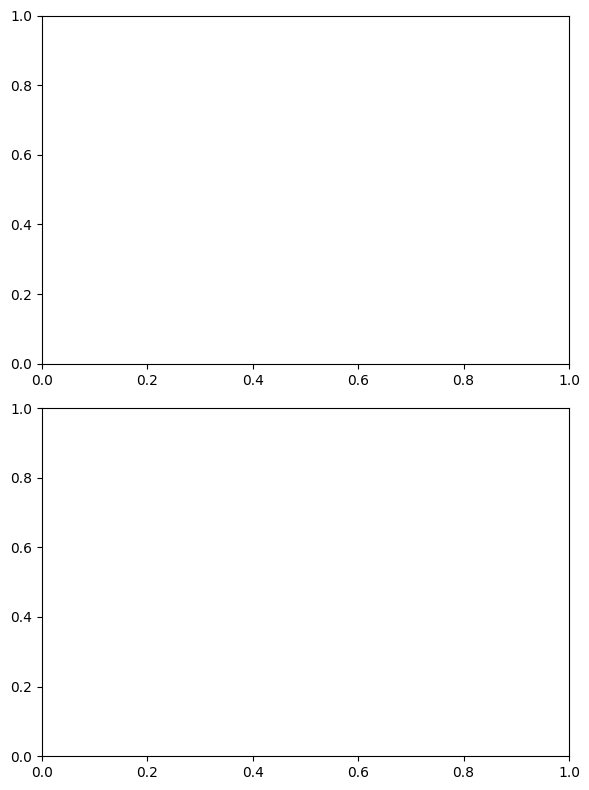


所有 1 次训练的统计信息:


In [8]:
# 方式1: 如果刚完成训练，使用 all_logs 变量
if 'all_logs' in globals() and len(all_logs) > 0:
    # 可视化所有训练日志
    import matplotlib.pyplot as plt
    
    n_runs = len(all_logs)
    fig, axes = plt.subplots(2, n_runs, figsize=(6*n_runs, 8))
    if n_runs == 1:
        axes = axes.reshape(2, 1)
    
    for run_id, training_log in enumerate(all_logs):
        if training_log is not None:
            log_df = pd.DataFrame(training_log)
            
            # 噪声分类准确率
            axes[0, run_id].plot(log_df['epoch'], log_df['validation_acc_noise'], 'b-o')
            axes[0, run_id].set_xlabel('Epoch')
            axes[0, run_id].set_ylabel('Noise Classification Accuracy')
            axes[0, run_id].set_title(f'Run {run_id+1}: Noise Classification Accuracy')
            axes[0, run_id].grid(True)
            
            # 单元分类F1分数
            axes[1, run_id].plot(log_df['epoch'], log_df['validation_acc_label'], 'r-o')
            axes[1, run_id].set_xlabel('Epoch')
            axes[1, run_id].set_ylabel('Unit Classification F1 Score')
            axes[1, run_id].set_title(f'Run {run_id+1}: Unit Classification F1 Score')
            axes[1, run_id].grid(True)
            
            print(f"\n训练 {run_id+1} 日志摘要:")
            print(log_df.tail())
    
    plt.tight_layout()
    plt.show()
    
    # 打印所有训练的统计信息
    print(f"\n所有 {n_runs} 次训练的统计信息:")
    for run_id, training_log in enumerate(all_logs):
        if training_log is not None:
            log_df = pd.DataFrame(training_log)
            min_acc_idx = log_df['validation_acc_noise'].idxmin()
            min_acc_epoch = log_df.loc[min_acc_idx, 'epoch']
            min_acc = log_df.loc[min_acc_idx, 'validation_acc_noise']
            print(f"  训练 {run_id+1}: 最小准确率 {min_acc:.6f} (Epoch {min_acc_epoch})")
            if 'base_model_save_dir' in globals():
                print(f"    日志路径: {base_model_save_dir}run_{run_id+1}/training_log.csv")
            else:
                print(f"    日志路径: model_save/run_{run_id+1}/training_log.csv")
else:
    # 方式2: 从文件读取训练日志（如果训练已完成）
    if 'base_model_save_dir' in globals():
        log_path = base_model_save_dir + 'training_log.csv'
    elif 'save_dir' in globals():
        log_path = save_dir + "model_save/training_log.csv"
    else:
        log_path = "model_save/training_log.csv"
    try:
        log_df = pd.read_csv(log_path, index_col=0)
        print(f"从文件读取训练日志: {log_path}")
        
        import matplotlib.pyplot as plt
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        axes[0].plot(log_df['epoch'], log_df['validation_acc_noise'], 'b-o')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Noise Classification Accuracy')
        axes[0].set_title('Noise Classification Accuracy')
        axes[0].grid(True)
        
        axes[1].plot(log_df['epoch'], log_df['validation_acc_label'], 'r-o')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Unit Classification F1 Score')
        axes[1].set_title('Unit Classification F1 Score')
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.show()
        
        print("\n训练日志摘要:")
        print(log_df.tail())
        
        print(f"\n完整训练日志路径: {log_path}")
    except FileNotFoundError:
        print(f"训练日志文件不存在: {log_path}")
        print("请先运行训练步骤")
